In [5]:
#1
import os, sys, copy, time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets, models

from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report
)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Paths / hyperparams (Updated for local offline usage)
LOCAL_INPUT_ROOT = "E:/Major Project/data2"                  # Base folder for your data
DATASET_FOLDER = "chest_xray"                # Folder containing train/val/test
DATA_ROOT = os.path.join(LOCAL_INPUT_ROOT, DATASET_FOLDER)

WORKING_DIR = "./e2_output"                     # Folder to save models and plots
os.makedirs(WORKING_DIR, exist_ok=True)      # Create it if it doesn't exist

IMG_SIZE = 224
BATCH = 16
NUM_WORKERS = 4
SEED = 42

EPOCHS_STAGE1 = 6
EPOCHS_STAGE2 = 10
LR_STAGE1 = 1e-4
LR_STAGE2 = 1e-5

USE_MIXUP = True
MIXUP_ALPHA = 0.2
USE_SAMPLER = False   # set True to use WeightedRandomSampler
FINE_TUNE_FRAC = 0.5  # fraction of feature-groups to freeze (unfreeze last 1-FINE_TUNE_FRAC)

Device: cuda


In [6]:
#2
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# check dataset location
if not os.path.isdir(DATA_ROOT):
    print(f"WARNING: DATA_ROOT not found: {DATA_ROOT}. Please ensure your data is placed here before running DataLoaders.")
else:
    print("Found dataset root:", DATA_ROOT)
    print("Subfolders:", os.listdir(DATA_ROOT))

Found dataset root: E:/Major Project/data2\chest_xray
Subfolders: ['test', 'train', 'val']


In [7]:
#3
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "val")
test_dir  = os.path.join(DATA_ROOT, "test")

# Note: Will raise an error if folders don't exist yet
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds   = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

print("Classes:", train_ds.classes)
print("Sizes -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

Classes: ['NORMAL', 'PNEUMONIA']
Sizes -> train: 4434 val: 798 test: 624


In [8]:
#4
def compute_class_counts(ds):
    c = Counter()
    for _, label in ds:
        c[int(label)] += 1
    return c

counts = compute_class_counts(datasets.ImageFolder(train_dir, transform=val_transform))
print("Train class counts:", counts)
neg = counts.get(0, 0)
pos = counts.get(1, 0)
pos_weight = torch.tensor([neg / max(1, pos)], dtype=torch.float32).to(DEVICE)
print("pos_weight:", pos_weight.item())

# optional weighted sampler
if USE_SAMPLER:
    class_sample_counts = [counts[i] for i in range(len(train_ds.classes))]
    weights = 1.0 / torch.tensor(class_sample_counts, dtype=torch.float)
    sample_weights = [weights[label] for _, label in datasets.ImageFolder(train_dir)]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
else:
    sampler = None

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          shuffle=(sampler is None), num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

Train class counts: Counter({1: 3294, 0: 1140})
pos_weight: 0.34608379006385803


In [9]:
#5
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y, None
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [10]:
#6
model = models.densenet121(pretrained=True)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)   # single logit for DenseNet
model = model.to(DEVICE)

# loss with pos_weight to handle imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# freeze features for stage1 (all children except 'classifier')
for name, child in model.named_children():
    if name != 'classifier':
        for p in child.parameters():
            p.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_STAGE1, weight_decay=1e-4)

print("Model created. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model created. Trainable params: 1025


In [11]:
#7
class EarlyStopping:
    """Stops training if validation metric doesn't improve after a given patience."""
    def __init__(self, patience=5, delta=0.0, mode='max', path='checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_metric, model):
        score = current_metric if self.mode == 'max' else -current_metric
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(current_metric, model)
        elif score <= self.best_score + self.delta:
            self.counter += 1
            print(f"  --> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(current_metric, model)
            self.counter = 0

    def save_checkpoint(self, current_metric, model):
        print(f"  --> Validation metric improved to {current_metric:.4f}. Saving model...")
        torch.save(model.state_dict(), self.path)

def train_one_epoch(model, loader, optimizer, criterion, device, use_mixup=USE_MIXUP, mixup_alpha=MIXUP_ALPHA):
    model.train()
    running_loss = 0.0
    all_logits, all_labels = [], []
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        if use_mixup:
            mixed_x, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            outputs = model(mixed_x)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
            soft_labels = (lam * y_a + (1 - lam) * y_b).detach().cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(soft_labels.tolist())
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().flatten().tolist())

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=running_loss / (len(all_labels) + 1e-9))

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_logits) >= 0.5).astype(int)
    true = np.array(all_labels).astype(int)
    acc = accuracy_score(true, preds) if len(true)>0 else float("nan")
    try:
        auc = roc_auc_score(true, np.array(all_logits))
    except Exception:
        auc = float("nan")
    return epoch_loss, acc, auc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Eval", leave=False):
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().flatten().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_logits) >= 0.5).astype(int)
    true = np.array(all_labels).astype(int)
    acc = accuracy_score(true, preds) if len(true)>0 else float("nan")
    try:
        auc = roc_auc_score(true, np.array(all_logits))
    except Exception:
        auc = float("nan")
    return epoch_loss, acc, auc, np.array(all_labels), np.array(all_logits)


STARTING TRAINING | CONFIG: MIXUP



e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--- Entering Stage 1 (Frozen Backbone) ---


Epoch 1/6 | Loss: 0.3324/0.3005 | Acc: 0.6058/0.7143 | AUC: 0.6411/0.8927
  --> Validation metric improved to 0.7143. Saving model...


Epoch 2/6 | Loss: 0.2827/0.2656 | Acc: 0.7068/0.6754 | AUC: 0.7386/0.9435
  --> EarlyStopping counter: 1 out of 3


...

Epoch 7/10 | Loss: 0.0430/0.0451 | Acc: 0.9700/0.9649 | AUC: 0.9957/0.9961
  --> EarlyStopping counter: 1 out of 4


Epoch 8/10 | Loss: 0.0416/0.0398 | Acc: 0.9736/0.9724 | AUC: 0.9958/0.9968
  --> Validation metric improved to 0.9724. Saving model...


Epoch 9/10 | Loss: 0.0382/0.0396 | Acc: 0.9736/0.9687 | AUC: 0.9964/0.9966
  --> EarlyStopping counter: 1 out of 4


Epoch 10/10 | Loss: 0.0332/0.0511 | Acc: 0.9768/0.9699 | AUC: 0.9975/0.9958
  --> EarlyStopping counter: 2 out of 4



==================== COMPARISON ====================

| Metric         | With MixUp   | Without MixUp   |
|:---------------|:-------------|:----------------|
| Test Accuracy  | 92.31%       | 91.03%          |
| Test AUC       | 0.9815       | 0.9811          |
| Best F1        | 0.9548       | 0.9560          |
| Best Threshold | 0.650        | 0.820           |




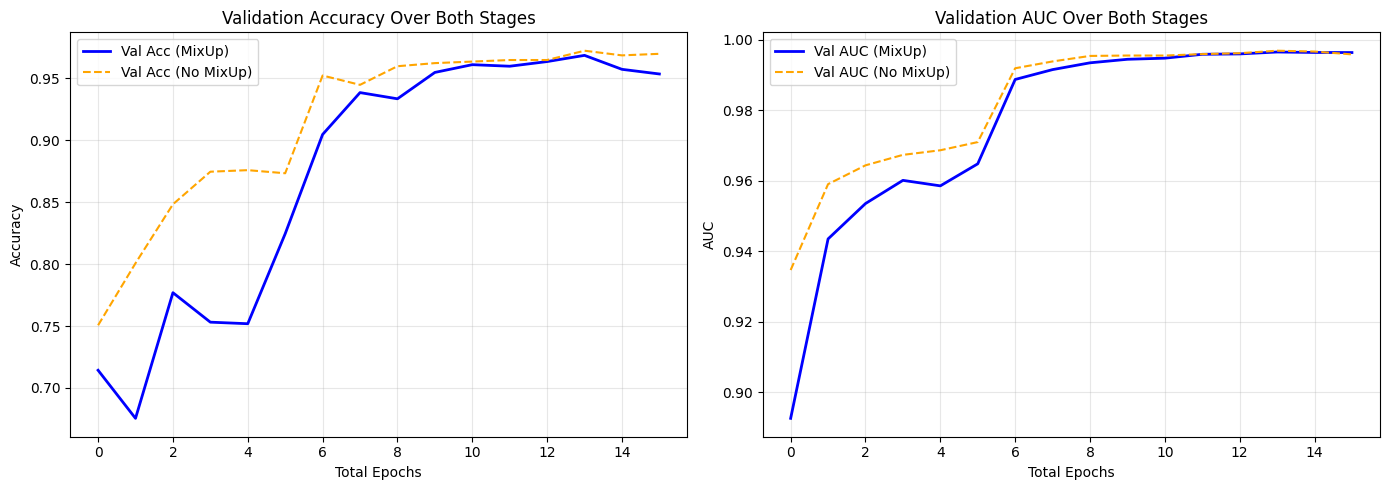

In [13]:
#8
def run_training(USE_MIXUP_FLAG):
    suffix = "mixup" if USE_MIXUP_FLAG else "nomixup"
    
    print("\n" + "="*50)
    print(f"STARTING TRAINING | CONFIG: {suffix.upper()}")
    print("="*50 + "\n")

    # Initialize DenseNet Model
    model = models.densenet121(pretrained=True)
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, 1)
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ==========================================
    # --- STAGE 1: Freeze Backbone ---
    # ==========================================
    for name, child in model.named_children():
        if name != 'classifier':
            for p in child.parameters():
                p.requires_grad = False
                
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_STAGE1)
    hist = {"train_acc":[], "val_acc":[], "train_auc":[], "val_auc":[], "train_loss":[], "val_loss":[]}

    # Setup unique path for Stage 1
    es_path_s1 = os.path.join(WORKING_DIR, f"best_s1_{suffix}.pth")
    es_s1 = EarlyStopping(patience=3, mode='max', path=es_path_s1)

    print(f"--- Entering Stage 1 (Frozen Backbone) ---")
    for epoch in range(EPOCHS_STAGE1):
        t_loss, t_acc, t_auc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, use_mixup=USE_MIXUP_FLAG)
        v_loss, v_acc, v_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        hist["train_acc"].append(t_acc); hist["val_acc"].append(v_acc)
        hist["train_auc"].append(t_auc); hist["val_auc"].append(v_auc)
        hist["train_loss"].append(t_loss); hist["val_loss"].append(v_loss)

        # Real-time metrics printout
        print(f"Epoch {epoch+1}/{EPOCHS_STAGE1} | "
              f"Loss: {t_loss:.4f}/{v_loss:.4f} | "
              f"Acc: {t_acc:.4f}/{v_acc:.4f} | "
              f"AUC: {t_auc:.4f}/{v_auc:.4f}")

        es_s1(v_acc, model)
        if es_s1.early_stop:
            print(f"Early Stopping Stage 1 ({suffix})")
            break

    # Load best weights from Stage 1 before unfreezing
    model.load_state_dict(torch.load(es_path_s1))

    # ==========================================
    # --- STAGE 2: Partial Unfreeze ---
    # ==========================================
    # Note: DenseNet wraps all convolutions inside 'features'
    feature_blocks = list(model.features.children())
    total_blocks = len(feature_blocks)
    fine_from = max(1, int(total_blocks * FINE_TUNE_FRAC))

    for i, child in enumerate(feature_blocks):
        requires = (i >= fine_from)
        for p in child.parameters():
            p.requires_grad = requires
            
    for p in model.classifier.parameters():
        p.requires_grad = True

    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR_STAGE2)

    # Setup unique path for Stage 2
    es_path_s2 = os.path.join(WORKING_DIR, f"best_s2_{suffix}.pth")
    es_s2 = EarlyStopping(patience=4, mode='max', path=es_path_s2)

    print(f"\n--- Entering Stage 2 (Fine-tuning from block {fine_from} of {total_blocks}) ---")
    for epoch in range(EPOCHS_STAGE2):
        t_loss, t_acc, t_auc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, use_mixup=USE_MIXUP_FLAG)
        v_loss, v_acc, v_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        hist["train_acc"].append(t_acc); hist["val_acc"].append(v_acc)
        hist["train_auc"].append(t_auc); hist["val_auc"].append(v_auc)
        hist["train_loss"].append(t_loss); hist["val_loss"].append(v_loss)

        # Real-time metrics printout
        print(f"Epoch {epoch+1}/{EPOCHS_STAGE2} | "
              f"Loss: {t_loss:.4f}/{v_loss:.4f} | "
              f"Acc: {t_acc:.4f}/{v_acc:.4f} | "
              f"AUC: {t_auc:.4f}/{v_auc:.4f}")

        es_s2(v_acc, model)
        if es_s2.early_stop:
            print(f"Early Stopping Stage 2 ({suffix})")
            break

    # Final Evaluation on Test Set
    model.load_state_dict(torch.load(es_path_s2))
    test_loss, test_acc, test_auc, y_true, y_probs = evaluate(model, test_loader, criterion, DEVICE)

    # Threshold Tuning
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.linspace(0.1, 0.9, 81):
        preds = (y_probs >= thr).astype(int)
        f1 = f1_score(y_true, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return {
        "history": hist, "test_acc": test_acc, "test_auc": test_auc,
        "test_loss": test_loss, "best_f1": best_f1, "best_thr": best_thr
    }

# ==========================================
# Run Comparison
# ==========================================
results_mix = run_training(USE_MIXUP_FLAG=True)
results_nomix = run_training(USE_MIXUP_FLAG=False)

# ==========================================
# --- DISPLAY RESULTS ---
# ==========================================
df = pd.DataFrame({
    "Metric": ["Test Accuracy", "Test AUC", "Best F1", "Best Threshold"],
    "With MixUp": [f"{results_mix['test_acc']*100:.2f}%", f"{results_mix['test_auc']:.4f}", f"{results_mix['best_f1']:.4f}", f"{results_mix['best_thr']:.3f}"],
    "Without MixUp": [f"{results_nomix['test_acc']*100:.2f}%", f"{results_nomix['test_auc']:.4f}", f"{results_nomix['best_f1']:.4f}", f"{results_nomix['best_thr']:.3f}"]
})

print("\n" + "="*20 + " COMPARISON " + "="*20 + "\n")
print(df.to_markdown(index=False))
print("\n" + "="*52 + "\n")

# ==========================================
# --- VISUALIZATION ---
# ==========================================
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(results_mix["history"]["val_acc"], label="Val Acc (MixUp)", color='blue', linewidth=2)
plt.plot(results_nomix["history"]["val_acc"], label="Val Acc (No MixUp)", color='orange', linestyle='--')
plt.title("Validation Accuracy Over Both Stages")
plt.xlabel("Total Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot AUC
plt.subplot(1, 2, 2)
plt.plot(results_mix["history"]["val_auc"], label="Val AUC (MixUp)", color='blue', linewidth=2)
plt.plot(results_nomix["history"]["val_auc"], label="Val AUC (No MixUp)", color='orange', linestyle='--')
plt.title("Validation AUC Over Both Stages")
plt.xlabel("Total Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
                                                     

Reloaded model test loss=0.1669 acc=0.9231 auc=0.9815
Best threshold by F1 (reloaded) = 0.650 (F1=0.9548)
Confusion Matrix (reloaded model):
 [[208  26]
 [ 10 380]]
Classification Report (reloaded model):
               precision    recall  f1-score   support

         0.0     0.9541    0.8889    0.9204       234
         1.0     0.9360    0.9744    0.9548       390

    accuracy                         0.9423       624
   macro avg     0.9450    0.9316    0.9376       624
weighted avg     0.9428    0.9423    0.9419       624



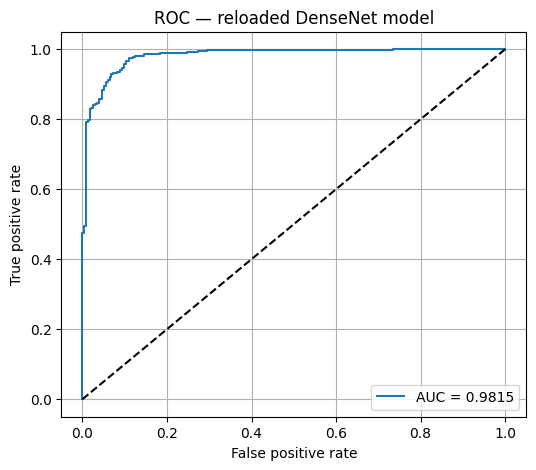

In [14]:
#9
# --- reload final model from disk and recompute confusion matrix ----
import torch
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

final_model_path = os.path.join(WORKING_DIR, "best_s2_mixup.pth")

# re‑construct DenseNet architecture exactly as in the notebook
model_reload = models.densenet121(pretrained=False)
num_features = model_reload.classifier.in_features
model_reload.classifier = torch.nn.Linear(num_features, 1)
model_reload.load_state_dict(torch.load(final_model_path, map_location=DEVICE))
model_reload.to(DEVICE)
model_reload.eval()

# evaluate on test set
loss_r, acc_r, auc_r, y_true_r, y_probs_r = evaluate(
    model_reload, test_loader, criterion, DEVICE
)
print(f"Reloaded model test loss={loss_r:.4f} acc={acc_r:.4f} auc={auc_r:.4f}")

# threshold search (reuse same loop you used earlier)
best_thr2, best_f12 = 0.5, 0.0
for thr in np.linspace(0.1, 0.9, 81):
    preds = (y_probs_r >= thr).astype(int)
    f1 = f1_score(y_true_r, preds)
    if f1 > best_f12:
        best_f12 = f1
        best_thr2 = thr
print(f"Best threshold by F1 (reloaded) = {best_thr2:.3f} (F1={best_f12:.4f})")

y_pred2 = (y_probs_r >= best_thr2).astype(int)
cm2 = confusion_matrix(y_true_r, y_pred2)
print("Confusion Matrix (reloaded model):\n", cm2)
print("Classification Report (reloaded model):\n",
      classification_report(y_true_r, y_pred2, digits=4))

# optional: plot ROC curve again
fpr2, tpr2, _ = roc_curve(y_true_r, y_probs_r)
plt.figure(figsize=(6,5))
plt.plot(fpr2, tpr2, label=f"AUC = {auc_r:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC — reloaded DenseNet model")
plt.legend(); plt.grid(True)
plt.show()

e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Major Project\env1\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
                                                     

Reloaded model test loss=0.2189 acc=0.9103 auc=0.9811
Best threshold by F1 (reloaded) = 0.820 (F1=0.9560)
Confusion Matrix (reloaded model):
 [[209  25]
 [ 10 380]]
Classification Report (reloaded model):
               precision    recall  f1-score   support

         0.0     0.9543    0.8932    0.9227       234
         1.0     0.9383    0.9744    0.9560       390

    accuracy                         0.9439       624
   macro avg     0.9463    0.9338    0.9394       624
weighted avg     0.9443    0.9439    0.9435       624



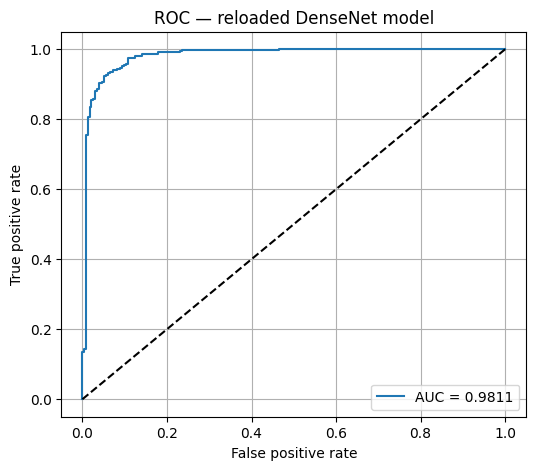

In [15]:
#9
# --- reload final model from disk and recompute confusion matrix ----
import torch
from torchvision import models
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

final_model_path = os.path.join(WORKING_DIR, "best_s2_nomixup.pth")

# re‑construct DenseNet architecture exactly as in the notebook
model_reload = models.densenet121(pretrained=False)
num_features = model_reload.classifier.in_features
model_reload.classifier = torch.nn.Linear(num_features, 1)
model_reload.load_state_dict(torch.load(final_model_path, map_location=DEVICE))
model_reload.to(DEVICE)
model_reload.eval()

# evaluate on test set
loss_r, acc_r, auc_r, y_true_r, y_probs_r = evaluate(
    model_reload, test_loader, criterion, DEVICE
)
print(f"Reloaded model test loss={loss_r:.4f} acc={acc_r:.4f} auc={auc_r:.4f}")

# threshold search (reuse same loop you used earlier)
best_thr2, best_f12 = 0.5, 0.0
for thr in np.linspace(0.1, 0.9, 81):
    preds = (y_probs_r >= thr).astype(int)
    f1 = f1_score(y_true_r, preds)
    if f1 > best_f12:
        best_f12 = f1
        best_thr2 = thr
print(f"Best threshold by F1 (reloaded) = {best_thr2:.3f} (F1={best_f12:.4f})")

y_pred2 = (y_probs_r >= best_thr2).astype(int)
cm2 = confusion_matrix(y_true_r, y_pred2)
print("Confusion Matrix (reloaded model):\n", cm2)
print("Classification Report (reloaded model):\n",
      classification_report(y_true_r, y_pred2, digits=4))

# optional: plot ROC curve again
fpr2, tpr2, _ = roc_curve(y_true_r, y_probs_r)
plt.figure(figsize=(6,5))
plt.plot(fpr2, tpr2, label=f"AUC = {auc_r:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC — reloaded DenseNet model")
plt.legend(); plt.grid(True)
plt.show()